# 05 - EDA: Roles, Languages and Remote Work
**Goal:** Compare salaries across job roles, programming languages and work arrangements. All comparisons use salary relative to the respondent's country median, so the country effect does not distort the results.






In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 13})

PRIMARY = "#4C72B0"
MUTED = "#9AA5B1"
ACCENT = "#C44E52"

DATA_PATH = Path("../data/processed/clean_salaries.csv")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists(), f"File not found: {DATA_PATH.resolve()}"

TARGET = "ConvertedCompYearly"
usd = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")

def save_fig(fig, name):
    """Save a figure to reports/figures with a consistent resolution."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

df = pd.read_csv(DATA_PATH, low_memory=False)

# Relative salary: 1.0 means "typical for that person's country"
country_median = df.groupby("Country")[TARGET].transform("median")
df["RelSalary"] = df[TARGET] / country_median

print(f"Loaded shape: {df.shape}")

Loaded shape: (21702, 15)


In [2]:
print("RemoteWork values:")
print(df["RemoteWork"].value_counts(dropna=False))

print("\nExample DevType values:")
print(df["DevType"].dropna().sample(5, random_state=1).tolist())

print("\nExample LanguageHaveWorkedWith values:")
print(df["LanguageHaveWorkedWith"].dropna().sample(3, random_state=1).tolist())

RemoteWork values:
RemoteWork
Remote                                                                          6755
Hybrid (some remote, leans heavy to in-person)                                  3977
Hybrid (some in-person, leans heavy to flexibility)                             3644
In-person                                                                       2899
Your choice (very flexible, you can come in when you want or just as needed)    2565
NaN                                                                             1862
Name: count, dtype: int64

Example DevType values:
['Developer, back-end', 'Developer, full-stack', 'Developer, full-stack', 'Developer, mobile', 'Developer, full-stack']

Example LanguageHaveWorkedWith values:
['HTML/CSS;Java;JavaScript;Python;SQL;TypeScript', 'HTML/CSS;JavaScript;PHP;PowerShell;SQL', 'Bash/Shell (all shells);C++;HTML/CSS;JavaScript;Python;Rust;TypeScript']


In [3]:
def explode_multiselect(frame, col, sep=";"):
    """Turn 'A;B;C' answers into one row per answer, keeping salary columns."""
    out = frame[["ResponseId", "Country", TARGET, "RelSalary", col]].dropna(subset=[col]).copy()
    out[col] = out[col].str.split(sep)
    out = out.explode(col)
    out[col] = out[col].str.strip()
    return out

roles = explode_multiselect(df, "DevType")
langs = explode_multiselect(df, "LanguageHaveWorkedWith")

print(f"Respondents with a role     : {df['DevType'].notna().sum():,}  -> exploded rows: {len(roles):,}")
print(f"Respondents with languages  : {df['LanguageHaveWorkedWith'].notna().sum():,}  -> exploded rows: {len(langs):,}")

Respondents with a role     : 21,702  -> exploded rows: 21,702
Respondents with languages  : 20,205  -> exploded rows: 121,586


,n,median_rel,median_usd
DevType,,,
"Senior executive (C-suite, VP, etc.)",296,1.60,139218.0
Engineering manager,692,1.42,131158.5
"Architect, software or solutions",1553,1.29,103633.0
Cloud infrastructure engineer,245,1.20,107894.0
AI/ML engineer,320,1.17,93062.0
DevOps engineer or professional,661,1.10,89739.0
"Developer, mobile",712,1.09,73190.5
"Developer, back-end",3697,1.09,81210.0
"Founder, technology or otherwise",176,1.09,94406.0


Saved: ..\reports\figures\05_salary_by_role.png


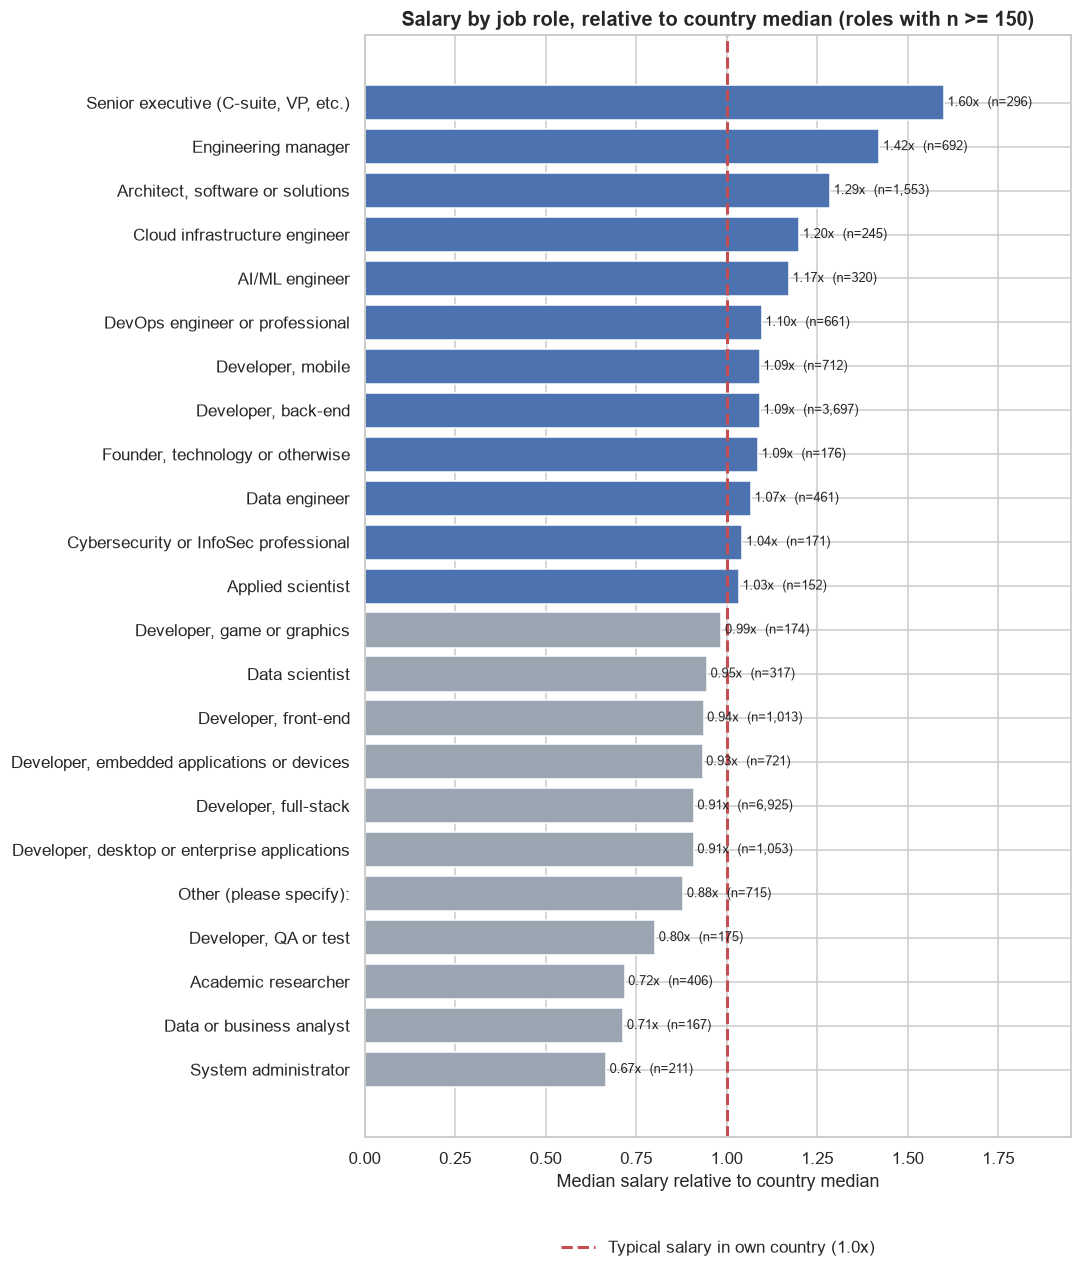

In [4]:
MIN_N_ROLE = 150   # ignore roles with too few respondents

role_stats = (
    roles.groupby("DevType")
         .agg(n=("RelSalary", "size"), median_rel=("RelSalary", "median"), median_usd=(TARGET, "median"))
         .query("n >= @MIN_N_ROLE")
         .sort_values("median_rel")
)
display(role_stats.sort_values("median_rel", ascending=False).round(2))

colors = [PRIMARY if v >= 1 else MUTED for v in role_stats["median_rel"]]

fig, ax = plt.subplots(figsize=(10, 0.42 * len(role_stats) + 2))
bars = ax.barh(role_stats.index, role_stats["median_rel"], color=colors)
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=2, label="Typical salary in own country (1.0x)")

for bar, med, n in zip(bars, role_stats["median_rel"], role_stats["n"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{med:.2f}x  (n={n:,})", va="center", fontsize=8.5)

ax.set_xlim(0, role_stats["median_rel"].max() * 1.22)
ax.set_title(f"Salary by job role, relative to country median (roles with n >= {MIN_N_ROLE})")
ax.set_xlabel("Median salary relative to country median")
ax.set_ylabel("")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.tight_layout()
save_fig(fig, "05_salary_by_role.png")
plt.show()

,n,median_rel,median_usd
LanguageHaveWorkedWith,,,
Ruby,1430,1.16,106733.0
Go,3476,1.13,93312.0
Swift,1085,1.13,95299.0
Groovy,1079,1.09,92812.0
Kotlin,2189,1.07,83857.0
Rust,2776,1.04,89229.0
Bash/Shell (all shells),10177,1.03,87272.0
TypeScript,9532,1.01,81895.0
Java,5649,1.00,81210.0


Saved: ..\reports\figures\06_salary_by_language.png


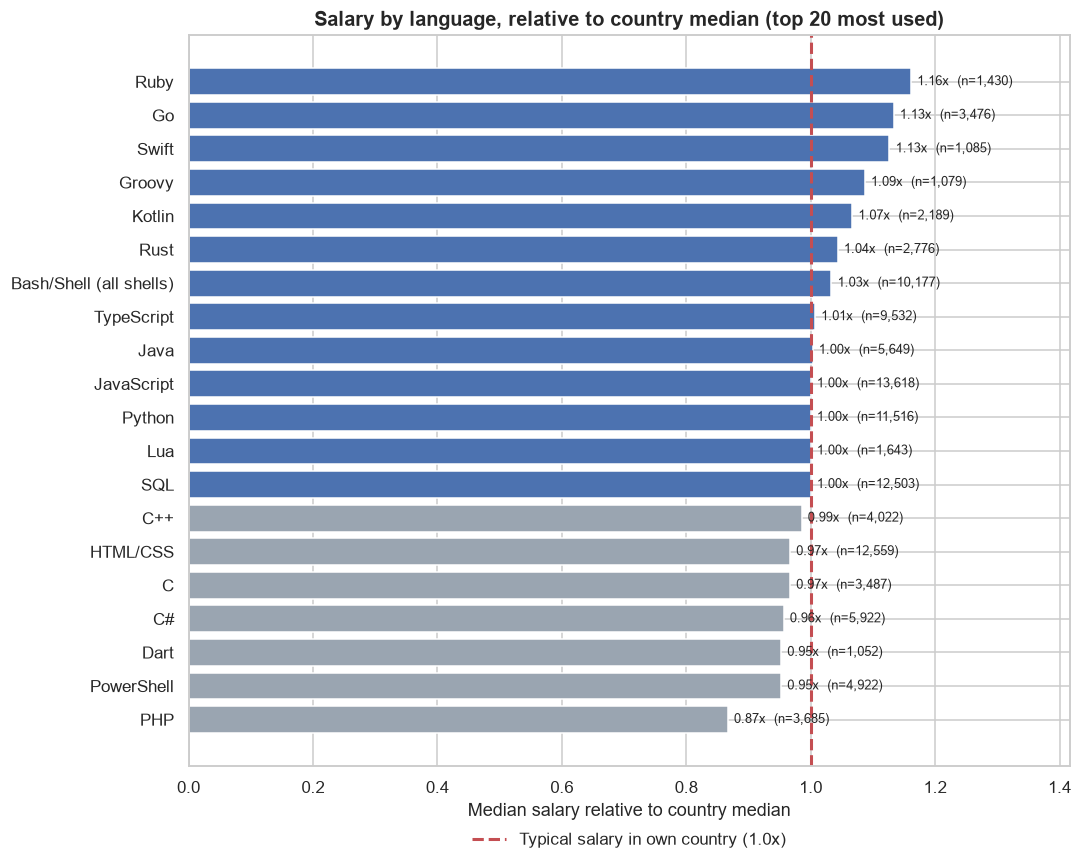

In [5]:
TOP_LANGS = 20   # compare only the 20 most used languages

lang_stats = (
    langs.groupby("LanguageHaveWorkedWith")
         .agg(n=("RelSalary", "size"), median_rel=("RelSalary", "median"), median_usd=(TARGET, "median"))
         .sort_values("n", ascending=False)
         .head(TOP_LANGS)
         .sort_values("median_rel")
)
display(lang_stats.sort_values("median_rel", ascending=False).round(2))

colors = [PRIMARY if v >= 1 else MUTED for v in lang_stats["median_rel"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(lang_stats.index, lang_stats["median_rel"], color=colors)
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=2, label="Typical salary in own country (1.0x)")

for bar, med, n in zip(bars, lang_stats["median_rel"], lang_stats["n"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{med:.2f}x  (n={n:,})", va="center", fontsize=8.5)

ax.set_xlim(0, lang_stats["median_rel"].max() * 1.22)
ax.set_title(f"Salary by language, relative to country median (top {TOP_LANGS} most used)")
ax.set_xlabel("Median salary relative to country median")
ax.set_ylabel("")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.07), frameon=False)
plt.tight_layout()
save_fig(fig, "06_salary_by_language.png")
plt.show()

,n,median_rel,median_usd
RemoteWork,,,
In-person,2899,0.75,51572.0
"Hybrid (some remote, leans heavy to in-person)",3977,0.93,75410.0
"Hybrid (some in-person, leans heavy to flexibility)",3644,1.00,81685.0
"Your choice (very flexible, you can come in when you want or just as needed)",2565,1.00,80254.0
Remote,6755,1.10,92812.0


Saved: ..\reports\figures\07_salary_by_remote_work.png


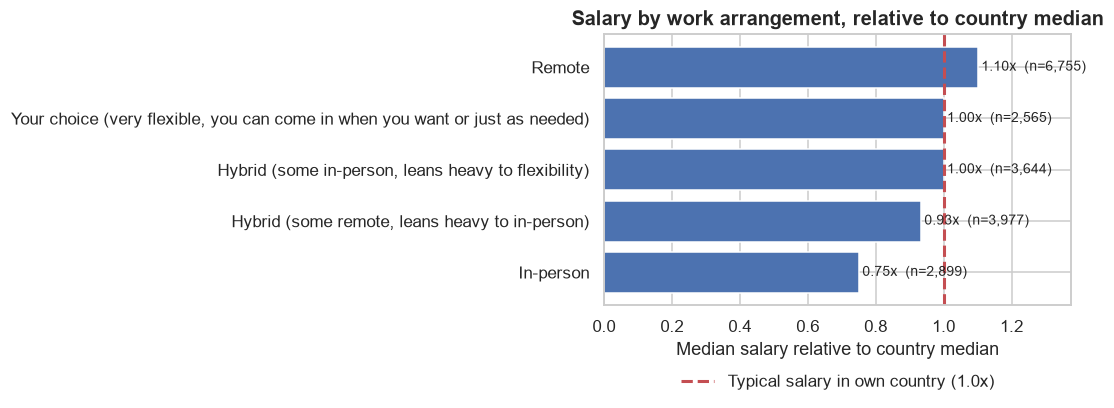

In [6]:
MIN_N_REMOTE = 100

remote_stats = (
    df.dropna(subset=["RemoteWork"])
      .groupby("RemoteWork")
      .agg(n=("RelSalary", "size"), median_rel=("RelSalary", "median"), median_usd=(TARGET, "median"))
      .query("n >= @MIN_N_REMOTE")
      .sort_values("median_rel")
)
display(remote_stats.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(remote_stats.index, remote_stats["median_rel"], color=PRIMARY)
ax.axvline(1.0, color=ACCENT, linestyle="--", linewidth=2, label="Typical salary in own country (1.0x)")

for bar, med, n in zip(bars, remote_stats["median_rel"], remote_stats["n"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{med:.2f}x  (n={n:,})", va="center", fontsize=9)

ax.set_xlim(0, remote_stats["median_rel"].max() * 1.25)
ax.set_title("Salary by work arrangement, relative to country median")
ax.set_xlabel("Median salary relative to country median")
ax.set_ylabel("")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), frameon=False)
plt.tight_layout()
save_fig(fig, "07_salary_by_remote_work.png")
plt.show()

In [7]:
top5 = df["Country"].value_counts().head(5).index.tolist()
MIN_CELL = 30

cr = (
    df[df["Country"].isin(top5)]
      .dropna(subset=["RemoteWork"])
      .groupby(["Country", "RemoteWork"])[TARGET]
      .agg(n="count", median="median")
      .reset_index()
)
cr.loc[cr["n"] < MIN_CELL, "median"] = np.nan

print("Median salary (USD) by country and work arrangement (cells with n < 30 hidden):")
display(cr.pivot(index="Country", columns="RemoteWork", values="median").round(0))

print("\nRespondents per cell:")
display(cr.pivot(index="Country", columns="RemoteWork", values="n"))

Median salary (USD) by country and work arrangement (cells with n < 30 hidden):


RemoteWork,"Hybrid (some in-person, leans heavy to flexibility)","Hybrid (some remote, leans heavy to in-person)",In-person,Remote,"Your choice (very flexible, you can come in when you want or just as needed)"
Country,,,,,
France,63808.0,58007.0,52207.0,74830.0,70189.0
Germany,87011.0,81210.0,71929.0,92812.0,87011.0
India,25573.0,23278.0,10462.0,25573.0,24410.0
United Kingdom,95299.0,92576.0,68071.0,102106.0,88492.0
United States,148500.0,140023.0,116000.0,165000.0,150000.0



Respondents per cell:


RemoteWork,"Hybrid (some in-person, leans heavy to flexibility)","Hybrid (some remote, leans heavy to in-person)",In-person,Remote,"Your choice (very flexible, you can come in when you want or just as needed)"
Country,,,,,
France,185,276,121,164,102
Germany,470,383,140,412,391
India,134,234,269,248,59
United Kingdom,353,217,120,420,196
United States,598,783,659,2159,395


In [8]:
print("Roles: highest 3 vs lowest 3 (relative to country median)")
display(pd.concat([role_stats.tail(3), role_stats.head(3)]).round(2))

print("\nLanguages: highest 3 vs lowest 3")
display(pd.concat([lang_stats.tail(3), lang_stats.head(3)]).round(2))

spread = remote_stats["median_rel"].max() - remote_stats["median_rel"].min()
print(f"\nSpread between best and worst work arrangement: {spread:.2f}x of country median")

Roles: highest 3 vs lowest 3 (relative to country median)


,n,median_rel,median_usd
DevType,,,
"Architect, software or solutions",1553,1.29,103633.0
Engineering manager,692,1.42,131158.5
"Senior executive (C-suite, VP, etc.)",296,1.60,139218.0
System administrator,211,0.67,58007.0
Data or business analyst,167,0.71,58007.0
Academic researcher,406,0.72,60000.0



Languages: highest 3 vs lowest 3


,n,median_rel,median_usd
LanguageHaveWorkedWith,,,
Swift,1085,1.13,95299.0
Go,3476,1.13,93312.0
Ruby,1430,1.16,106733.0
PHP,3685,0.87,65000.0
PowerShell,4922,0.95,83902.0
Dart,1052,0.95,58445.0



Spread between best and worst work arrangement: 0.35x of country median


In [9]:
# Do high-paying roles simply have more experienced people?
role_exp = (
    df.groupby("DevType")
      .agg(n=("WorkExp", "size"), median_exp=("WorkExp", "median"))
      .query("n >= 150")
      .join(role_stats[["median_rel"]])
      .sort_values("median_rel", ascending=False)
)
display(role_exp.round(2))
corr = role_exp["median_exp"].corr(role_exp["median_rel"])
print(f"Correlation between a role's median experience and its relative salary: {corr:.2f}")

# Median experience by work arrangement
remote_exp = (
    df.dropna(subset=["RemoteWork"])
      .groupby("RemoteWork")["WorkExp"].median()
      .rename("median_experience_years")
)
display(remote_exp)

# Remote vs in-person gap inside the US, controlling for experience bucket
us = df[(df["Country"] == "United States") & df["RemoteWork"].isin(["Remote", "In-person"])].copy()
us["ExpBucket"] = pd.cut(us["WorkExp"], bins=[0, 5, 10, 20, 70],
                         labels=["0-5", "6-10", "11-20", "21+"], include_lowest=True)

gap = (
    us.groupby(["ExpBucket", "RemoteWork"], observed=True)[TARGET]
      .agg(n="count", median="median")
      .unstack("RemoteWork")
)
print("\nUS median salary by experience bucket: remote vs in-person")
display(gap.round(0))

,n,median_exp,median_rel
DevType,,,
"Senior executive (C-suite, VP, etc.)",296,20.0,1.60
Engineering manager,692,17.0,1.42
"Architect, software or solutions",1553,19.0,1.29
Cloud infrastructure engineer,245,11.0,1.20
AI/ML engineer,320,8.0,1.17
DevOps engineer or professional,661,12.0,1.10
"Developer, back-end",3697,11.0,1.09
"Developer, mobile",712,10.0,1.09
"Founder, technology or otherwise",176,17.0,1.09


Correlation between a role's median experience and its relative salary: 0.64


RemoteWork
Hybrid (some in-person, leans heavy to flexibility)                             12.0
Hybrid (some remote, leans heavy to in-person)                                  10.0
In-person                                                                        8.0
Remote                                                                          13.0
Your choice (very flexible, you can come in when you want or just as needed)    11.0
Name: median_experience_years, dtype: float64


US median salary by experience bucket: remote vs in-person


n           median          
RemoteWork In-person Remote In-person    Remote
ExpBucket                                      
0-5              188    203   83480.0  107000.0
6-10             148    445  125500.0  152000.0
11-20            152    780  145790.0  176900.0
21+              150    720  159500.0  175000.0